In [56]:
import pandas as pd
import os
from pathlib import Path
import duckdb
from collections import defaultdict
import string
import matplotlib.pyplot as plt
import matplotlib
import numpy as np

In [3]:
usage_db = duckdb.connect("usage_db.duckdb")

In [ ]:
usage_db.

In [9]:
row_count = usage_db.execute("SELECT COUNT(*) FROM trips").fetchone()[0]
columns_info = usage_db.execute("PRAGMA table_info('trips')").fetchdf()

In [13]:
print(f"Rows: {row_count}, Columns: {len(columns_info)}")
print(columns_info)

Rows: 107997137, Columns: 10
   cid                name       type  notnull dflt_value     pk
0    0           rental_id     BIGINT    False       None  False
1    1             bike_id     BIGINT    False       None  False
2    2          bike_model    VARCHAR    False       None  False
3    3          start_date  TIMESTAMP    False       None  False
4    4            end_date  TIMESTAMP    False       None  False
5    5    start_station_id     BIGINT    False       None  False
6    6  start_station_name    VARCHAR    False       None  False
7    7      end_station_id     BIGINT    False       None  False
8    8    end_station_name    VARCHAR    False       None  False
9    9    duration_seconds     DOUBLE    False       None  False


In [23]:
col_names = columns_info["name"].tolist()

null_exprs = ",\n    ".join(
    f"COUNT(*) FILTER (WHERE \"{col}\" IS NULL) AS \"{col}\""
    for col in col_names
)

null_counts = usage_db.execute(f"""
    SELECT
    {null_exprs}
    FROM trips
""").fetchdf()


In [27]:
null_counts

,rental_id,bike_id,bike_model,start_date,end_date,start_station_id,start_station_name,end_station_id,end_station_name,duration_seconds
0,0,44,106335967,0,0,0,0,329960,238524,0


In [29]:
yearly = usage_db.execute("""
    SELECT
        YEAR(start_date) AS year,
        COUNT(*)         AS trip_count
    FROM trips
    GROUP BY year
    ORDER BY year
""").fetchdf()

In [30]:
yearly

,year,trip_count
0,2012,4846951
1,2013,7421836
2,2014,9895412
3,2015,12655258
4,2016,10642121
5,2017,10139839
6,2018,10441884
7,2019,10310063
8,2020,10287040
9,2021,10821289


Trip Duration

In [53]:
durations = usage_db.execute("""
    SELECT
        duration_seconds
    FROM trips
""").fetchdf()

In [54]:
 durations

,duration_seconds
0,240.0
1,300.0
2,1200.0
3,780.0
4,600.0
...,...
107997132,240.0
107997133,960.0
107997134,1140.0
107997135,180.0


In [ ]:
filtered_dur = durations[(durations["duration_seconds"] > 0) & (durations["duration_seconds"] < 14400)]
counts, bins = np.histogram(filtered_dur,   bins = 1000)

(array([8.108000e+03, 3.856000e+03, 3.769000e+03, 3.340000e+03,
        3.485640e+05, 1.383100e+04, 2.050400e+04, 3.161300e+04,
        1.124977e+06, 5.038600e+04, 6.542900e+04, 7.133700e+04,
        2.413214e+06, 9.077000e+04, 9.833300e+04, 1.139360e+05,
        3.422042e+06, 1.270610e+05, 1.241670e+05, 1.293920e+05,
        4.012963e+06, 1.353380e+05, 1.478690e+05, 1.398740e+05,
        4.327022e+06, 1.533760e+05, 1.446970e+05, 1.566990e+05,
        1.468380e+05, 4.539610e+06, 1.594000e+05, 1.483830e+05,
        1.588620e+05, 4.620367e+06, 1.464500e+05, 1.562330e+05,
        1.444740e+05, 4.617155e+06, 1.422640e+05, 1.409010e+05,
        1.486620e+05, 4.520992e+06, 1.453470e+05, 1.343470e+05,
        1.316080e+05, 4.408398e+06, 1.287900e+05, 1.352020e+05,
        1.244550e+05, 4.239776e+06, 1.304390e+05, 1.195440e+05,
        1.264840e+05, 1.154780e+05, 4.048401e+06, 1.196970e+05,
        1.102440e+05, 1.163600e+05, 3.838436e+06, 1.040870e+05,
        1.092370e+05, 1.001560e+05, 3.63

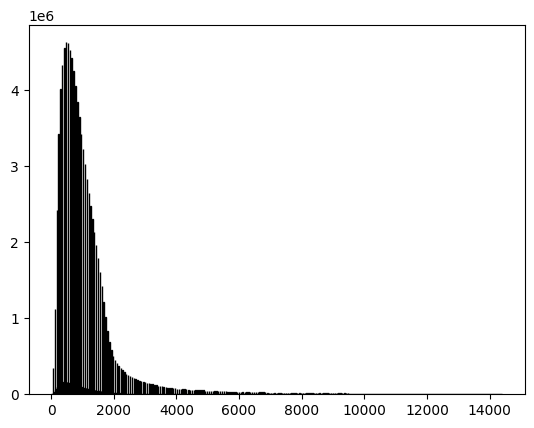

In [78]:
plt.hist(filtered_dur, bins=1000, edgecolor="black")

In [79]:
filtered_dur_1hour = durations[(durations["duration_seconds"] > 0) & (durations["duration_seconds"] <= 3600)]


(array([2.739000e+03, 2.645000e+03, 1.291000e+03, 1.433000e+03,
        8.390000e+02, 1.019000e+03, 9.240000e+02, 1.074000e+03,
        1.200000e+03, 7.390000e+02, 9.470000e+02, 8.830000e+02,
        6.600000e+02, 8.730000e+02, 7.450000e+02, 1.062000e+03,
        3.436740e+05, 1.196000e+03, 1.922000e+03, 1.772000e+03,
        2.893000e+03, 3.369000e+03, 3.084000e+03, 4.485000e+03,
        3.708000e+03, 5.513000e+03, 6.282000e+03, 5.001000e+03,
        7.467000e+03, 6.035000e+03, 8.558000e+03, 9.553000e+03,
        7.668000e+03, 1.095823e+06, 8.850000e+03, 1.263600e+04,
        1.320800e+04, 1.062700e+04, 1.483000e+04, 1.172100e+04,
        1.634800e+04, 1.718800e+04, 1.334100e+04, 1.855200e+04,
        1.449700e+04, 2.009400e+04, 2.061200e+04, 1.613400e+04,
        2.158400e+04, 2.343626e+06, 2.360900e+04, 2.439500e+04,
        1.876200e+04, 2.571600e+04, 1.978500e+04, 2.650700e+04,
        2.750000e+04, 2.084800e+04, 2.838100e+04, 2.160400e+04,
        2.974800e+04, 2.980500e+04, 2.29

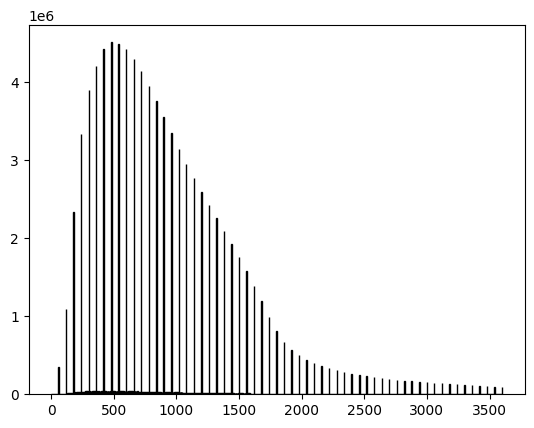

In [81]:
plt.hist(filtered_dur_1hour, bins=1000, edgecolor="black")